##Counterfactual Clinical Decision Support using Temporal Transformers on EHR Data

##Imports

In [2]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


##Set random seed

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

##Create synthetic demo dataset

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['Colab Notebooks', 'ServerMachineDataset', 'mimic-iv-clinical-database-demo-2.2', 'archive (4).zip']


In [4]:
import pandas as pd

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

patients = pd.read_csv(f"{base_path}/hosp/patients.csv.gz", compression='gzip')
admissions = pd.read_csv(f"{base_path}/hosp/admissions.csv.gz", compression='gzip')
icustays = pd.read_csv(f"{base_path}/icu/icustays.csv.gz", compression='gzip')

labevents = pd.read_csv(
    f"{base_path}/hosp/labevents.csv.gz",
    compression='gzip',
    nrows=50000,
    parse_dates=['charttime']
)

chartevents = pd.read_csv(
    f"{base_path}/icu/chartevents.csv.gz",
    compression='gzip',
    nrows=50000,
    parse_dates=['charttime']
)

try:
    prescriptions = pd.read_csv(
        f"{base_path}/hosp/prescriptions.csv.gz",
        compression='gzip',
        nrows=20000
    )
except FileNotFoundError:
    prescriptions = None
    print("prescriptions.csv.gz not found")

patients = patients.drop_duplicates(subset='subject_id')
admissions = admissions.drop_duplicates(subset=['subject_id', 'hadm_id'])
icustays = icustays.drop_duplicates(subset='stay_id')

print("ICU columns:", icustays.columns.tolist())
print("Admissions columns:", admissions.columns.tolist())
print("Patients columns:", patients.columns.tolist())

data = icustays.merge(
    admissions,
    on=['subject_id', 'hadm_id'],
    how='left'
)

data = data.merge(
    patients,
    on='subject_id',
    how='left'
)

if 'hospital_expire_flag' in data.columns:
    data['mortality'] = data['hospital_expire_flag'].fillna(0).astype(int)
else:
    data['mortality'] = 0
    print("Warning: hospital_expire_flag not found")

labevents = labevents.sort_values(by=['subject_id', 'charttime'])
chartevents = chartevents.sort_values(by=['subject_id', 'charttime'])

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("ICU stays:", icustays.shape)
print("Lab events:", labevents.shape)
print("Chart events:", chartevents.shape)

print("\nMerged Data Sample:")
print(data.head())

ICU columns: ['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los']
Admissions columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']
Patients columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
Patients: (100, 6)
Admissions: (275, 16)
ICU stays: (140, 8)
Lab events: (50000, 16)
Chart events: (50000, 11)

Merged Data Sample:
   subject_id   hadm_id   stay_id  \
0    10018328  23786647  31269608   
1    10020187  24104168  37509585   
2    10020187  26842957  32554129   
3    10012853  27882036  31338022   
4    10020740  25826145  32145159   

                                    first_careunit        last_careunit  \
0                                   Neuro Stepdown       Neuro Stepdown   
1  Neuro Surg

#merge data and feature eng

In [5]:
import pandas as pd

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

patients = pd.read_csv(f"{base_path}/hosp/patients.csv.gz", compression='gzip')
admissions = pd.read_csv(f"{base_path}/hosp/admissions.csv.gz", compression='gzip')
icustays = pd.read_csv(f"{base_path}/icu/icustays.csv.gz", compression='gzip')

patients = patients[['subject_id', 'gender', 'anchor_age']]
admissions = admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'hospital_expire_flag']]
icustays = icustays[['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime']]

patients = patients.drop_duplicates('subject_id')
admissions = admissions.drop_duplicates(['subject_id', 'hadm_id'])
icustays = icustays.drop_duplicates('stay_id')

df = pd.merge(patients, admissions, on='subject_id', how='inner')
df = pd.merge(df, icustays, on=['subject_id', 'hadm_id'], how='inner')

df['admittime'] = pd.to_datetime(df['admittime'])
df['dischtime'] = pd.to_datetime(df['dischtime'])
df['intime'] = pd.to_datetime(df['intime'])
df['outtime'] = pd.to_datetime(df['outtime'])

df['hospital_los'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / 86400
df['icu_los'] = (df['outtime'] - df['intime']).dt.total_seconds() / 86400

df['mortality'] = df['hospital_expire_flag'].fillna(0).astype(int)

df['gender'] = df['gender'].map({'M': 1, 'F': 0})

df = df.dropna().reset_index(drop=True)

print("Final dataset shape:", df.shape)
print(df.head())

Final dataset shape: (140, 13)
   subject_id  gender  anchor_age   hadm_id           admittime  \
0    10014729       0          21  28889419 2125-02-27 07:15:00   
1    10003400       0          72  23559586 2137-08-04 00:07:00   
2    10003400       0          72  23559586 2137-08-04 00:07:00   
3    10003400       0          72  20214994 2137-02-24 10:00:00   
4    10002428       0          80  28662225 2156-04-12 14:16:00   

            dischtime  hospital_expire_flag   stay_id              intime  \
0 2125-03-06 14:25:00                     0  33558396 2125-02-27 10:03:08   
1 2137-09-02 17:05:00                     1  38383343 2137-08-17 17:36:37   
2 2137-09-02 17:05:00                     1  34577403 2137-08-10 19:54:51   
3 2137-03-19 15:45:00                     0  32128372 2137-02-25 23:37:19   
4 2156-04-29 16:26:00                     0  38875437 2156-04-19 18:11:19   

              outtime  hospital_los    icu_los  mortality  
0 2125-03-01 21:21:37      7.298611   2.471

##View sample data

In [6]:
# shape + preview
print(df.shape)
print(df.head())

print("\nUnique patients:", df["subject_id"].nunique())

# FIX 1: admission_type add safely

import pandas as pd

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

admissions_extra = pd.read_csv(
    f"{base_path}/hosp/admissions.csv.gz",
    compression='gzip',
    usecols=['subject_id', 'hadm_id', 'admission_type']
)

admissions_extra = admissions_extra.drop_duplicates(['subject_id', 'hadm_id'])

# avoid duplicate admission_type column
if 'admission_type' in df.columns:
    df = df.drop(columns=['admission_type'])

df = df.merge(
    admissions_extra,
    on=['subject_id', 'hadm_id'],
    how='left'
)

df['admission_type'] = df['admission_type'].fillna('UNKNOWN')

df["treatment"] = df["admission_type"].astype("category").cat.codes.astype(int)

print("Unique treatments:", sorted(df["treatment"].unique()))
print("Treatment mapping:")

treatment_mapping = dict(
    enumerate(df["admission_type"].astype("category").cat.categories)
)

print(treatment_mapping)


# FIX 2: outcome

df["outcome"] = df["mortality"].fillna(0).astype(int)

print("Outcome distribution:\n", df["outcome"].value_counts())

(140, 13)
   subject_id  gender  anchor_age   hadm_id           admittime  \
0    10014729       0          21  28889419 2125-02-27 07:15:00   
1    10003400       0          72  23559586 2137-08-04 00:07:00   
2    10003400       0          72  23559586 2137-08-04 00:07:00   
3    10003400       0          72  20214994 2137-02-24 10:00:00   
4    10002428       0          80  28662225 2156-04-12 14:16:00   

            dischtime  hospital_expire_flag   stay_id              intime  \
0 2125-03-06 14:25:00                     0  33558396 2125-02-27 10:03:08   
1 2137-09-02 17:05:00                     1  38383343 2137-08-17 17:36:37   
2 2137-09-02 17:05:00                     1  34577403 2137-08-10 19:54:51   
3 2137-03-19 15:45:00                     0  32128372 2137-02-25 23:37:19   
4 2156-04-29 16:26:00                     0  38875437 2156-04-19 18:11:19   

              outtime  hospital_los    icu_los  mortality  
0 2125-03-01 21:21:37      7.298611   2.471169          0  
1 21

##Preprocess into sequences

In [7]:
import pandas as pd
import numpy as np

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

labevents = pd.read_csv(
    f"{base_path}/hosp/labevents.csv.gz",
    compression='gzip',
    nrows=50000,
    parse_dates=['charttime']
)

labevents = labevents[['subject_id', 'hadm_id', 'charttime', 'valuenum']]
labevents = labevents.dropna()

mean_val = labevents['valuenum'].mean()
std_val = labevents['valuenum'].std()

labevents['abnormal_flag'] = (
    (labevents['valuenum'] > mean_val + std_val) |
    (labevents['valuenum'] < mean_val - std_val)
).astype(int)

agg = labevents.groupby(['subject_id', 'hadm_id']).agg(
    Total_lab_events=('valuenum', 'count'),
    Abnormal_counts=('abnormal_flag', 'sum'),
    mean_lab_value=('valuenum', 'mean'),
    std_lab_value=('valuenum', 'std')
).reset_index()

agg['Normal_counts'] = agg['Total_lab_events'] - agg['Abnormal_counts']
agg['abnormal_rate'] = agg['Abnormal_counts'] / agg['Total_lab_events']

# remove old columns if rerun cell
old_cols = [
    'Total_lab_events',
    'Abnormal_counts',
    'Normal_counts',
    'abnormal%',
    'abnormal_rate',
    'mean_lab_value',
    'std_lab_value'
]

df = df.drop(columns=[c for c in old_cols if c in df.columns])

df = df.merge(agg, on=['subject_id', 'hadm_id'], how='left')
df = df.fillna(0)

feature_cols = [
    "anchor_age",
    "hospital_los",
    "icu_los",
    "Normal_counts",
    "Abnormal_counts",
    "Total_lab_events",
    "abnormal_rate",
    "mean_lab_value",
    "std_lab_value"
]

X_list, T_list, y_list = [], [], []

for pid, group in df.groupby("subject_id"):
    group = group.sort_values("admittime")

    x_seq = group[feature_cols].values
    t_seq = group["treatment"].values

    # mortality outcome: if patient died in any admission = 1
    label = group["outcome"].max()

    X_list.append(x_seq)
    T_list.append(t_seq)
    y_list.append(label)

X = np.array(X_list, dtype=object)
T = np.array(T_list, dtype=object)
y = np.array(y_list, dtype=np.float32)

print("Total patients:", len(X))
print("Example sequence shape:", X[0].shape)
print("Feature count:", X[0].shape[1])
print("Outcome distribution:", pd.Series(y).value_counts())

Total patients: 100
Example sequence shape: (1, 9)
Feature count: 9
Outcome distribution: 0.0    85
1.0    15
Name: count, dtype: int64


##Normalize features

##Normalize features

In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

X_padded = pad_sequences(X, padding='post', dtype='float32', value=0.0)
T_padded = pad_sequences(T, padding='post', dtype='int32', value=0)

# mask: 1 = real data, 0 = padding
mask_padded = (np.abs(X_padded).sum(axis=-1) != 0).astype(np.float32)

print("X padded shape:", X_padded.shape)
print("T padded shape:", T_padded.shape)
print("Mask shape:", mask_padded.shape)

X padded shape: (100, 5, 9)
T padded shape: (100, 5)
Mask shape: (100, 5)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# split first
X_train, X_test, T_train, T_test, mask_train, mask_test, y_train, y_test = train_test_split(
    X_padded, T_padded, mask_padded, y,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) > 1 else None
)

N_train, S, F = X_train.shape

scaler = StandardScaler()

# reshape
X_train_2d = X_train.reshape(-1, F)
X_test_2d = X_test.reshape(-1, F)

# only scale valid (non-padding)
train_valid = mask_train.reshape(-1) == 1
test_valid = mask_test.reshape(-1) == 1

X_train_2d[train_valid] = scaler.fit_transform(X_train_2d[train_valid])
X_test_2d[test_valid] = scaler.transform(X_test_2d[test_valid])

# reshape back
X_train = X_train_2d.reshape(X_train.shape)
X_test = X_test_2d.reshape(X_test.shape)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (80, 5, 9)
Test shape: (20, 5, 9)


##Train/test split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, T_train, T_test, mask_train, mask_test, y_train, y_test = train_test_split(
    X_padded,
    T_padded,
    mask_padded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) > 1 else None
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (80, 5, 9) (80,)
Test : (20, 5, 9) (20,)


##Dataset and DataLoader

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class EHRDataset(Dataset):
    def __init__(self, X, T, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.T = torch.tensor(T, dtype=torch.long)
        self.mask = torch.tensor(mask, dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.T[idx], self.mask[idx], self.y[idx]


# create dataset
train_dataset = EHRDataset(X_train, T_train, mask_train, y_train)
test_dataset  = EHRDataset(X_test, T_test, mask_test, y_test)

# dataloader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# debug
batch_X, batch_T, batch_mask, batch_y = next(iter(train_loader))

print("X batch shape:", batch_X.shape)
print("T batch shape:", batch_T.shape)
print("Mask shape:", batch_mask.shape)
print("y batch shape:", batch_y.shape)

X batch shape: torch.Size([64, 5, 9])
T batch shape: torch.Size([64, 5])
Mask shape: torch.Size([64, 5])
y batch shape: torch.Size([64])


##Positional encoding

In [15]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len].to(x.device)
        return x

##Temporal Transformer with treatment embedding

In [16]:
import torch
import torch.nn as nn

class CounterfactualTemporalTransformer(nn.Module):
    def __init__(self, num_features, num_treatments, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()

        self.feature_proj = nn.Linear(num_features, d_model)
        self.treatment_embed = nn.Embedding(num_treatments, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, treatment_seq, valid_mask):
        # valid_mask: True = real data, False = padding
        padding_mask = ~valid_mask

        x_embed = self.feature_proj(x)
        t_embed = self.treatment_embed(treatment_seq)

        h = x_embed + t_embed
        h = self.pos_encoder(h)

        h = self.transformer(
            h,
            src_key_padding_mask=padding_mask
        )

        valid_mask_f = valid_mask.unsqueeze(-1).float()

        pooled = (h * valid_mask_f).sum(dim=1) / valid_mask_f.sum(dim=1).clamp(min=1)

        logits = self.classifier(pooled).squeeze(-1)

        return logits

##Initialize model

In [17]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_features = X_train.shape[-1]
num_treatments = int(max(T_train.max(), T_test.max())) + 1

model = CounterfactualTemporalTransformer(
    num_features=num_features,
    num_treatments=num_treatments,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(model)

CounterfactualTemporalTransformer(
  (feature_proj): Linear(in_features=9, out_features=64, bias=True)
  (treatment_embed): Embedding(6, 64)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dro

##Training loop

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import torch

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x_batch, t_batch, mask_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        t_batch = t_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch, t_batch, mask_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x_batch, t_batch, mask_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            t_batch = t_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch, t_batch, mask_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    preds = (all_probs >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = np.nan

    return total_loss / len(loader), acc, auc

##Run training

In [20]:
num_epochs = 15

train_losses = []
test_losses = []
test_acc_list = []
test_auc_list = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc, test_auc = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_acc_list.append(test_acc)
    test_auc_list.append(test_auc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"ACC: {test_acc:.4f} | "
        f"AUC: {test_auc:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/15 | Train Loss: 0.5749 | Test Loss: 0.4626 | ACC: 0.8500 | AUC: 0.4706
Epoch 2/15 | Train Loss: 0.4092 | Test Loss: 0.4317 | ACC: 0.8500 | AUC: 0.4902
Epoch 3/15 | Train Loss: 0.4458 | Test Loss: 0.4237 | ACC: 0.8500 | AUC: 0.5294
Epoch 4/15 | Train Loss: 0.3668 | Test Loss: 0.4266 | ACC: 0.8500 | AUC: 0.4706
Epoch 5/15 | Train Loss: 0.4459 | Test Loss: 0.4331 | ACC: 0.8500 | AUC: 0.4118
Epoch 6/15 | Train Loss: 0.4898 | Test Loss: 0.4411 | ACC: 0.8500 | AUC: 0.3922
Epoch 7/15 | Train Loss: 0.3593 | Test Loss: 0.4530 | ACC: 0.8500 | AUC: 0.3725
Epoch 8/15 | Train Loss: 0.3676 | Test Loss: 0.4555 | ACC: 0.8500 | AUC: 0.4510
Epoch 9/15 | Train Loss: 0.4645 | Test Loss: 0.4512 | ACC: 0.8500 | AUC: 0.4902
Epoch 10/15 | Train Loss: 0.4640 | Test Loss: 0.4402 | ACC: 0.8500 | AUC: 0.5490
Epoch 11/15 | Train Loss: 0.3329 | Test Loss: 0.4303 | ACC: 0.8500 | AUC: 0.6471
Epoch 12/15 | Train Loss: 0.4523 | Test Loss: 0.4263 | ACC: 0.8500 | AUC: 0.7451
Epoch 13/15 | Train Loss: 0.3845 | Te

##Plot training history

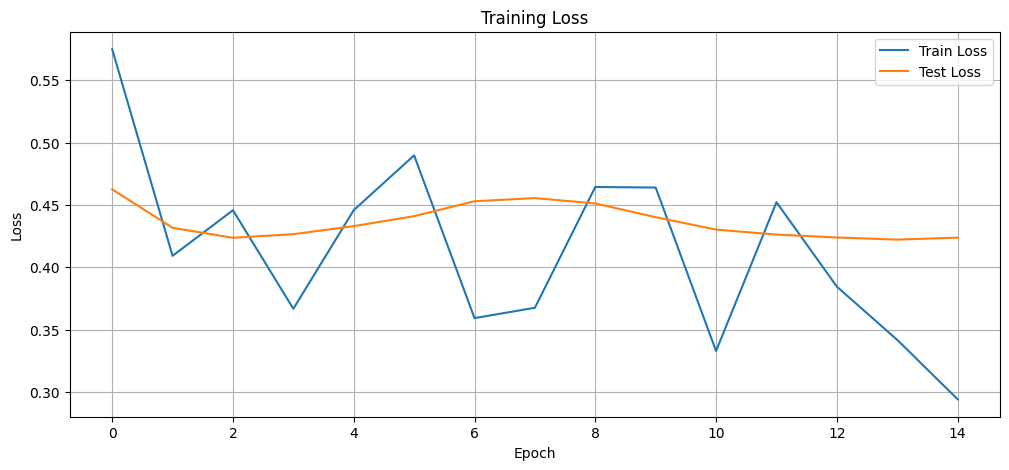

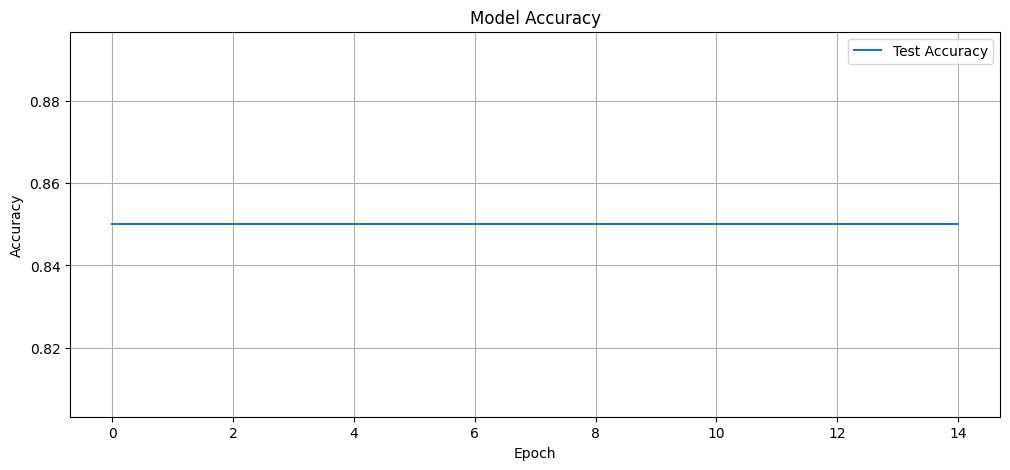

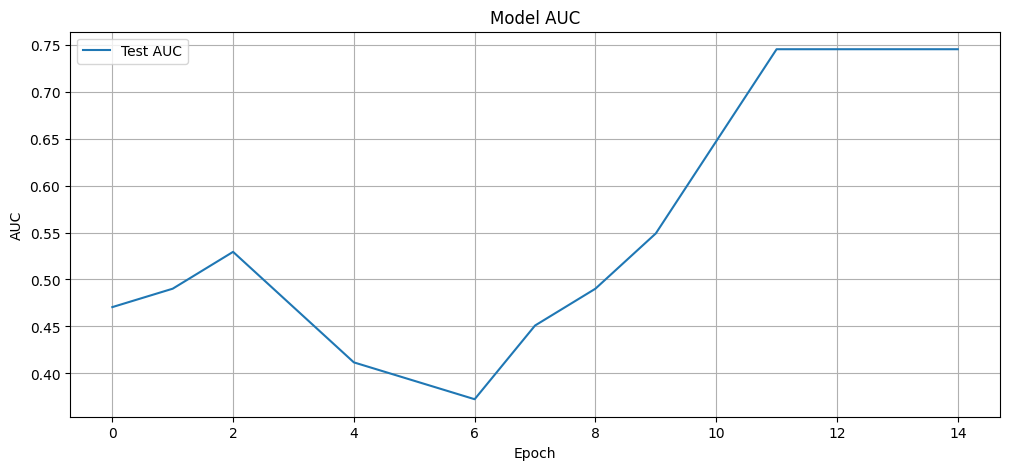

In [21]:
import matplotlib.pyplot as plt

# Loss Plot
plt.figure(figsize=(12,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()


# Accuracy Plot
plt.figure(figsize=(12,5))
plt.plot(test_acc_list, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# AUC Plot
plt.figure(figsize=(12,5))
plt.plot(test_auc_list, label="Test AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Model AUC")
plt.legend()
plt.grid(True)
plt.show()

##Counterfactual prediction function

In [22]:
def predict_counterfactual_outcomes(model, patient_x, patient_mask, num_treatments):
    """
    patient_x: [seq_len, num_features]
    patient_mask: [seq_len]
    """

    model.eval()
    results = {}

    with torch.no_grad():
        x_tensor = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)
        mask_tensor = torch.tensor(patient_mask, dtype=torch.bool).unsqueeze(0).to(device)

        seq_len = patient_x.shape[0]

        for tr in range(num_treatments):
            t_tensor = torch.full((1, seq_len), tr, dtype=torch.long).to(device)

            logits = model(x_tensor, t_tensor, mask_tensor)
            prob = torch.sigmoid(logits).item()

            results[tr] = prob

    return results

##Test on one patient

In [23]:
import torch
import numpy as np

def predict_counterfactual_outcomes(model, patient_x, patient_mask, num_treatments):
    model.eval()

    x_tensor = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)
    mask_tensor = torch.tensor(patient_mask, dtype=torch.bool).unsqueeze(0).to(device)

    results = {}

    with torch.no_grad():
        for t in range(num_treatments):
            t_seq = torch.full(
                (1, x_tensor.shape[1]),
                t,
                dtype=torch.long
            ).to(device)

            logits = model(x_tensor, t_seq, mask_tensor)
            prob = torch.sigmoid(logits).item()

            if np.isnan(prob) or np.isinf(prob):
                prob = 0.0

            results[t] = prob

    return results


# Run Example
sample_idx = 0

patient_x = X_test[sample_idx]
patient_mask = mask_test[sample_idx]

results = predict_counterfactual_outcomes(
    model,
    patient_x,
    patient_mask,
    num_treatments=num_treatments
)

# if you created treatment_mapping earlier, use it
try:
    treatment_names = treatment_mapping
except NameError:
    treatment_names = {i: f"Treatment {i}" for i in range(num_treatments)}

print("Counterfactual mortality risk for same patient:\n")

for k, v in results.items():
    label = "High Risk" if v >= 0.5 else "Low Risk"
    print(f"{treatment_names.get(k, f'Treatment {k}')} -> Risk: {v:.4f} -> {label}")

Counterfactual mortality risk for same patient:

DIRECT EMER. -> Risk: 0.1145 -> Low Risk
ELECTIVE -> Risk: 0.1147 -> Low Risk
EW EMER. -> Risk: 0.1145 -> Low Risk
OBSERVATION ADMIT -> Risk: 0.1149 -> Low Risk
SURGICAL SAME DAY ADMISSION -> Risk: 0.1147 -> Low Risk
URGENT -> Risk: 0.1147 -> Low Risk


##Visualize counterfactual comparison

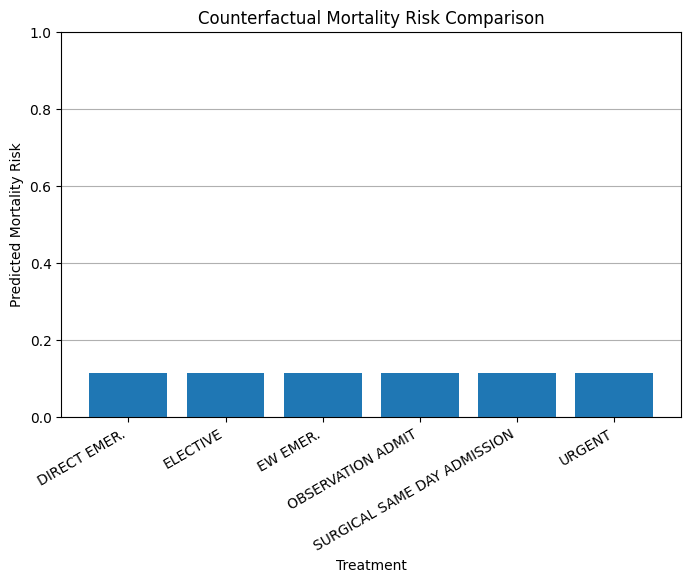

Counterfactual results:
DIRECT EMER. -> Risk: 0.1145
ELECTIVE -> Risk: 0.1147
EW EMER. -> Risk: 0.1145
OBSERVATION ADMIT -> Risk: 0.1149
SURGICAL SAME DAY ADMISSION -> Risk: 0.1147
URGENT -> Risk: 0.1147


In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# pick patient from test set
sample_idx = 0
patient_x = X_test[sample_idx]
patient_mask = mask_test[sample_idx]

def predict_counterfactual_outcomes(model, patient_x, patient_mask, num_treatments):
    model.eval()

    x_tensor = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)
    mask_tensor = torch.tensor(patient_mask, dtype=torch.bool).unsqueeze(0).to(device)

    results = {}

    with torch.no_grad():
        for t in range(num_treatments):
            t_seq = torch.full(
                (1, x_tensor.shape[1]),
                t,
                dtype=torch.long
            ).to(device)

            logits = model(x_tensor, t_seq, mask_tensor)
            prob = torch.sigmoid(logits).item()

            if np.isnan(prob) or np.isinf(prob):
                prob = 0.0

            results[t] = prob

    return results


results = predict_counterfactual_outcomes(
    model,
    patient_x,
    patient_mask,
    num_treatments
)

try:
    treatment_names = treatment_mapping
except NameError:
    treatment_names = {i: f"T{i}" for i in range(num_treatments)}

labels = [str(treatment_names.get(k, f"T{k}")) for k in results.keys()]
values = list(results.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Counterfactual Mortality Risk Comparison")
plt.ylabel("Predicted Mortality Risk")
plt.xlabel("Treatment")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

print("Counterfactual results:")
for k, v in results.items():
    print(f"{treatment_names.get(k, f'Treatment {k}')} -> Risk: {v:.4f}")

##Show patient trajectory

patient_x shape: (5, 9)
valid timesteps: 1
patient_df shape: (1, 9)
   anchor_age  hospital_los   icu_los  Normal_counts  Abnormal_counts  \
0        28.0      4.270833  1.186169           95.0              0.0   

   Total_lab_events  abnormal_rate  mean_lab_value  std_lab_value  
0              95.0            0.0       50.519581      71.378288  


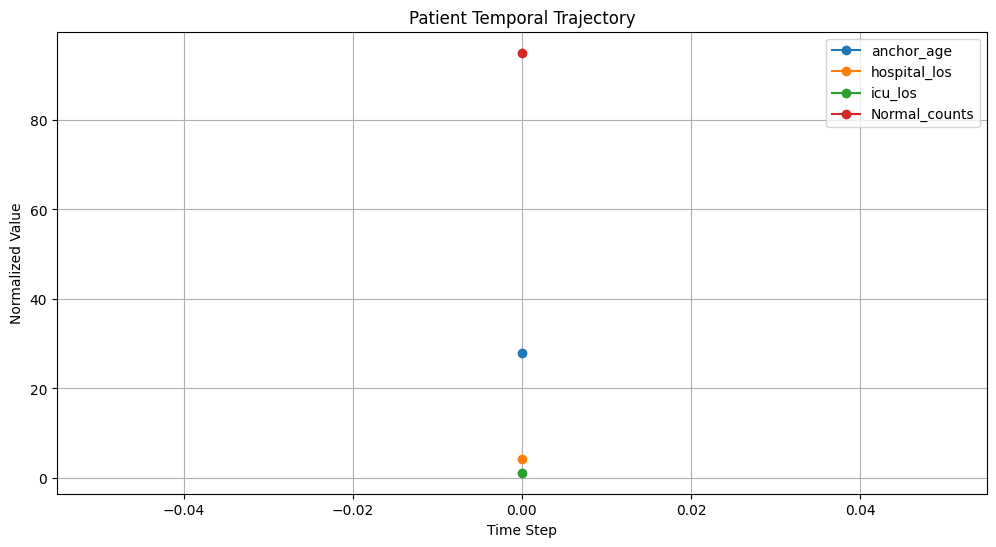

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

patient_df = pd.DataFrame(patient_x, columns=feature_cols)

# safe mask
valid_idx = np.array(patient_mask).astype(bool)

print("patient_x shape:", patient_x.shape)
print("valid timesteps:", valid_idx.sum())

# if mask removes everything, do not filter
if valid_idx.sum() > 0:
    patient_df = patient_df.loc[valid_idx].reset_index(drop=True)
else:
    print("Mask empty, plotting full sequence")

print("patient_df shape:", patient_df.shape)
print(patient_df.head())

plt.figure(figsize=(12,6))

for col in patient_df.columns[:4]:
    plt.plot(
        patient_df.index,
        patient_df[col],
        marker='o',
        label=col
    )

plt.xlabel("Time Step")
plt.ylabel("Normalized Value")
plt.title("Patient Temporal Trajectory")
plt.legend()
plt.grid(True)
plt.show()

##Generate table output

In [27]:
import pandas as pd

if "results" not in globals():
    raise Exception("❌ 'results' not found. Run counterfactual prediction first.")

summary_rows = []

for tr, prob in results.items():
    summary_rows.append({
        "Treatment": treatment_names.get(tr, f"Treatment {tr}"),
        "Predicted Risk Probability": round(float(prob), 4),
        "Predicted Outcome": "High Risk" if prob >= 0.5 else "Low Risk"
    })

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values(by="Predicted Risk Probability")
summary_df.reset_index(drop=True, inplace=True)

summary_df

,Treatment,Predicted Risk Probability,Predicted Outcome
0,DIRECT EMER.,0.1145,Low Risk
1,EW EMER.,0.1145,Low Risk
2,ELECTIVE,0.1147,Low Risk
3,SURGICAL SAME DAY ADMISSION,0.1147,Low Risk
4,URGENT,0.1147,Low Risk
5,OBSERVATION ADMIT,0.1149,Low Risk
